# Advection 1D périodique

In [1]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr

import matplotlib.colors as colors

Nx = 128
dx = 0.0078125
c=100.0
dt = 7.8125e-07
u_sum(0) = 31.834164319855336


C:\Users\evanl\miniforge3\envs\classic_env\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\evanl\miniforge3\envs\classic_env\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(31.0, 33.0)

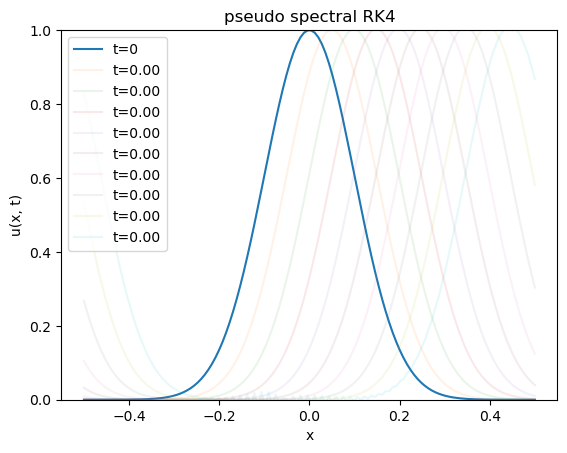

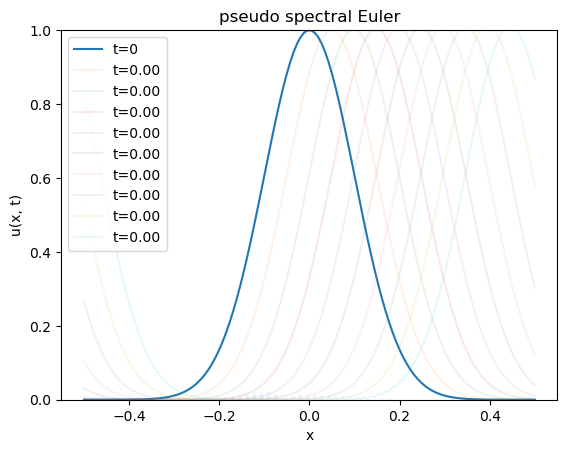

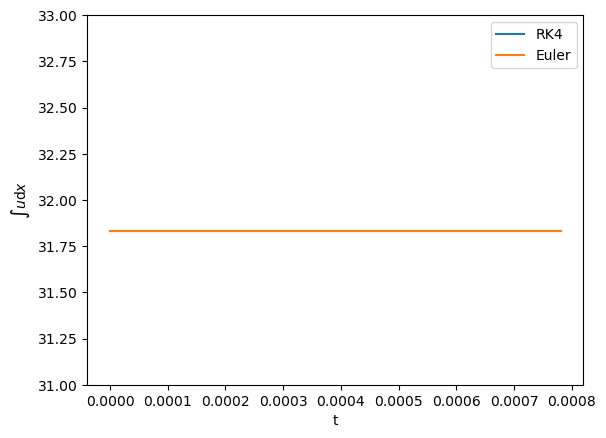

In [3]:
L = 1.0

Nx = 128

print(f"Nx = {Nx}")

x = np.linspace(-L/2., L/2., Nx)

sigma = 0.1
u0 = np.exp( -x**2/(2.*sigma**2) )
u = u0.copy()

dx = L/Nx

CFL = 0.01

print(f"dx = {dx}")

c=100.0
print(f"c={c}")


dt = CFL*dx/c
#dt =1.0e-6


print(f"dt = {dt}")

Nt = 1000

u_res = [u]

t=0.0
t_tot = [t]

time_scheme ='Euler'

u_int = u

def RK4(x, rhs, delta_t, *args, **kwargs):
    k1 = rhs(x, *args, **kwargs)
    k2 = rhs(x+0.5*delta_t*k1, *args, **kwargs)
    k3 = rhs(x+0.5*delta_t*k2, *args, **kwargs)
    k4 = rhs(x+delta_t*k3, *args, **kwargs)

    return x+delta_t*(k1+2.0*k2+2.0*k3+k4)/6.0

def u_tot(U):
    return np.sum(U)
def rhs_adv(x):
    return -c*dx_Fourier_1D(u, a=-L/2., b=L/2., real =False)

u_int =[u_tot(u)]
print(f"u_sum(0) = {u_tot(u0)}")

u_euler = u0.copy()
u_euler_t = [u_euler]
u_int_euler = [u_tot(u)]

for i in range(0, Nt):
    u_euler = u_euler - c*dt*dx_Fourier_1D(u_euler, a=-L/2., b=L/2.)#intégration par méthode d'Euler
    u = RK4(u, rhs_adv, dt)
    u_res.append(u)
    u_int.append(u_tot(u))
    u_int_euler.append(u_tot(u_euler))
    u_euler_t.append(u_euler)
    t+=dt
    t_tot.append(t)


Da_1D = xr.DataArray(np.array(u_res).real, dims=['t', 'x'], coords = {'x' : x, 't':t_tot})

step_plot =100

fig = plt.figure()
plt.title("pseudo spectral RK4")
plt.plot(x, u0, label='t=0')
for i in range(1, Nt):
    if i %step_plot ==0 : 
        plt.plot(x, u_res[i], label=f't={i*dt:.2f}', alpha =0.1)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)

fig = plt.figure()
plt.title("pseudo spectral Euler")
plt.plot(x, u0, label='t=0')
for i in range(1, Nt):
    if i %step_plot ==0 : 
        plt.plot(x, u_euler_t[i], label=f't={i*dt:.2f}', alpha =0.1)
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.legend()
plt.ylim(bottom=0.0, top=1.0)



fig = plt.figure()
plt.plot(t_tot, u_int, label = 'RK4')
plt.plot(t_tot, u_int, label='Euler')
plt.xlabel('t')
plt.ylabel(r'$\int u \mathrm{d}x$')
plt.legend()
plt.ylim(31., 33.)